# Problem Statement

 "Develop a machine learning classification model to predict whether a candidate will be hired based on their resume attributes, including education, experience, skills, and achievements."

# Business Context

  Organizations receive a large number of job applications and face challenges in manually screening candidates efficiently and consistently.

Traditional hiring processes:

*  Time-consuming

* Subjective decision-making

* Risk of overlooking qualified candidates

To address this, the company aims to build an automated hiring prediction system that can assist recruiters in identifying suitable candidates quickly.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score, classification_report, f1_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

In [2]:
df= pd.read_csv('/content/resume_dataset_200k_enhanced.csv')

In [3]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

df.drop(columns=['candidate_id'], inplace=True, errors='ignore')

df.head()

,age,education_level,university_tier,cgpa,internships,projects,programming_languages,certifications,experience_years,hackathons,research_papers,skills_score,hired,soft_skills_score,resume_length_words,company_type
0,27,Bachelors,Tier 2,8.16,2,7,2,2,0.33,0,0,21.0,1,5.62,409,MNC
1,24,Bachelors,Tier 3,6.35,3,2,2,2,4.99,0,0,11.0,1,9.66,237,Startup
2,33,Bachelors,Tier 3,7.78,0,2,4,2,0.93,0,0,15.0,1,8.12,435,Startup
3,31,Masters,Tier 3,6.92,2,1,4,1,0.37,0,0,11.5,1,7.19,340,MNC
4,28,Masters,Tier 2,8.24,3,0,1,2,0.33,0,0,5.0,0,4.09,371,Mid-size


In [4]:
df.shape

(200000, 16)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   age                    200000 non-null  int64  
 1   education_level        200000 non-null  object 
 2   university_tier        200000 non-null  object 
 3   cgpa                   200000 non-null  float64
 4   internships            200000 non-null  int64  
 5   projects               200000 non-null  int64  
 6   programming_languages  200000 non-null  int64  
 7   certifications         200000 non-null  int64  
 8   experience_years       200000 non-null  float64
 9   hackathons             200000 non-null  int64  
 10  research_papers        200000 non-null  int64  
 11  skills_score           200000 non-null  float64
 12  hired                  200000 non-null  int64  
 13  soft_skills_score      200000 non-null  float64
 14  resume_length_words    200000 non-nu

In [6]:
df.describe()

,age,cgpa,internships,projects,programming_languages,certifications,experience_years,hackathons,research_papers,skills_score,hired,soft_skills_score,resume_length_words
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,27.511705,7.499323,1.503015,2.996240,3.004420,1.000985,1.499030,0.498005,0.201950,14.000803,0.706060,6.502866,449.206975
std,4.030684,0.800952,1.225373,1.731104,1.412229,1.002217,1.497477,0.706773,0.448806,4.766263,0.455566,2.019637,120.103065
min,21.000000,4.150000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,3.000000,-79.000000
25%,24.000000,6.960000,1.000000,2.000000,2.000000,0.000000,0.430000,0.000000,0.000000,10.500000,0.000000,4.750000,368.000000
50%,28.000000,7.500000,1.000000,3.000000,3.000000,1.000000,1.040000,0.000000,0.000000,14.000000,1.000000,6.510000,449.000000
75%,31.000000,8.040000,2.000000,4.000000,4.000000,2.000000,2.080000,1.000000,0.000000,17.000000,1.000000,8.250000,530.000000
max,34.000000,11.230000,10.000000,14.000000,5.000000,8.000000,23.550000,6.000000,5.000000,38.500000,1.000000,10.000000,956.000000


In [7]:
df.isnull().sum()

,0
age,0
education_level,0
university_tier,0
cgpa,0
internships,0
projects,0
programming_languages,0
certifications,0
experience_years,0
hackathons,0


In [8]:
df.duplicated().sum()

np.int64(0)

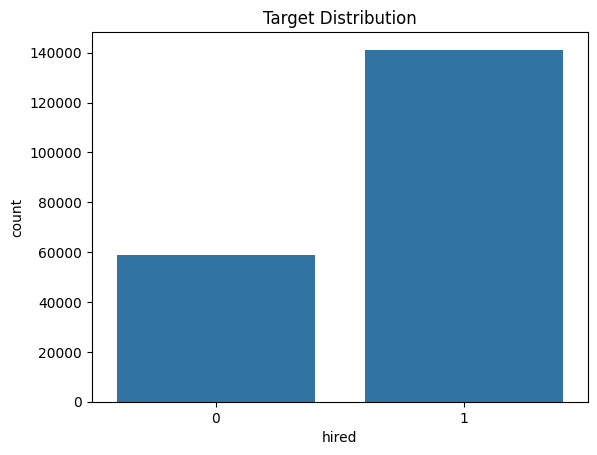

In [9]:
sns.countplot(x=df['hired'])
plt.title("Target Distribution")
plt.show()

#### Numerical Distribution

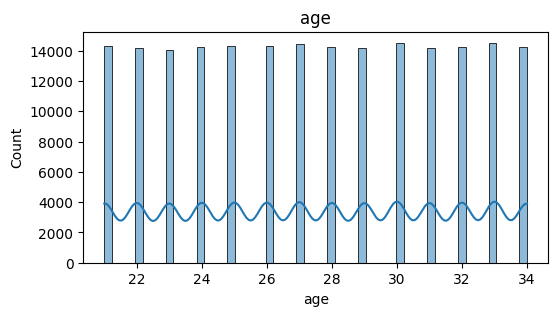

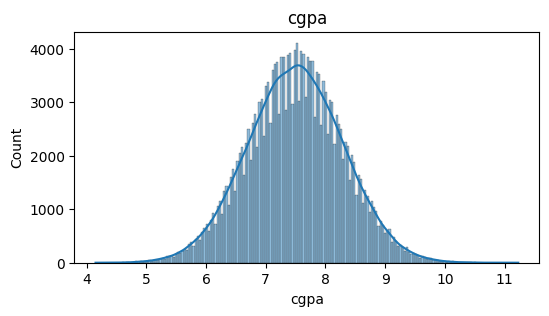

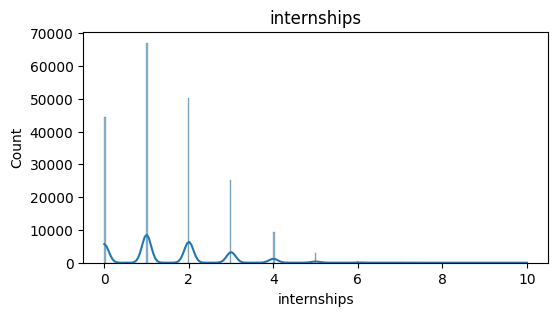

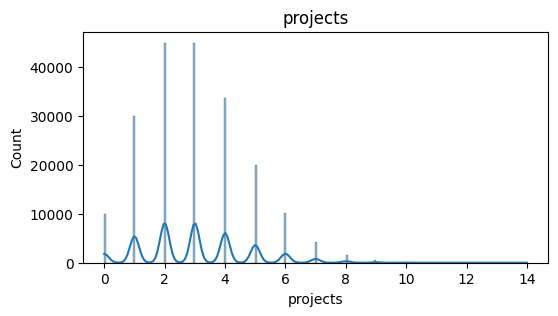

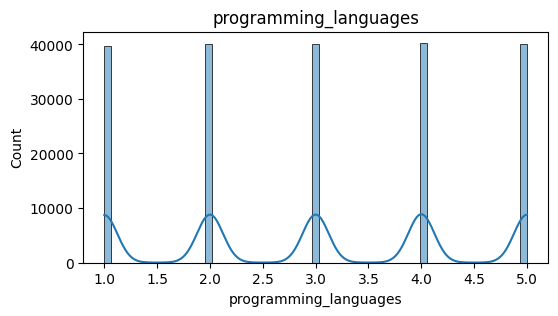

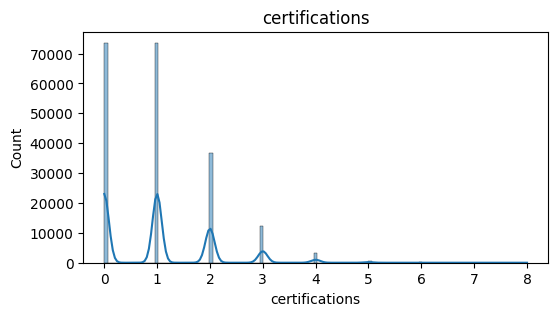

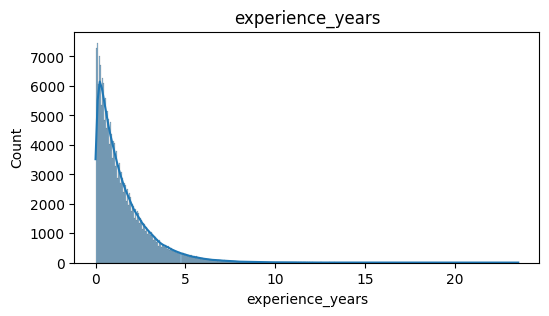

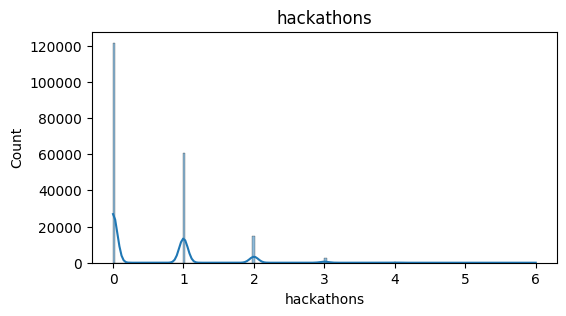

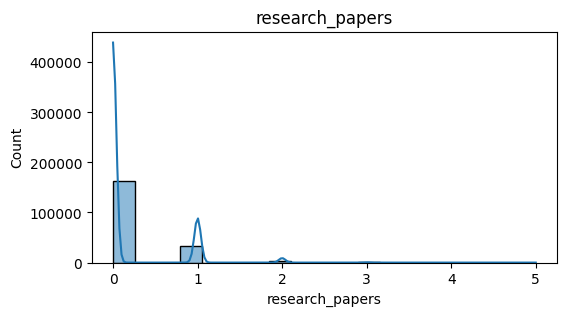

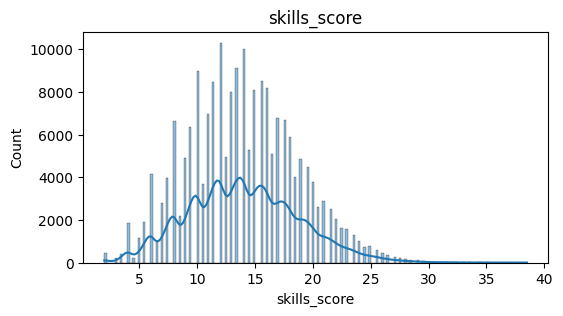

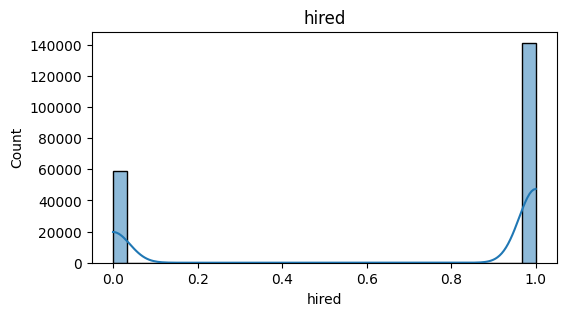

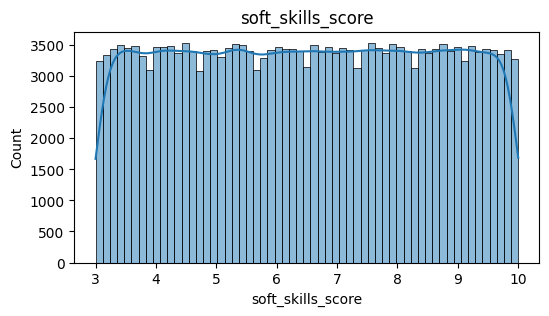

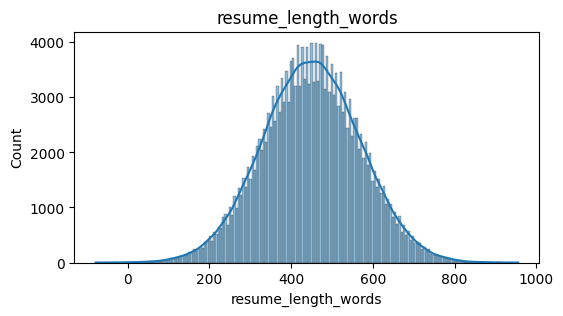

In [10]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

#### Observation:

* Skewness in count features
* Outliers present

### Categorical Distribution

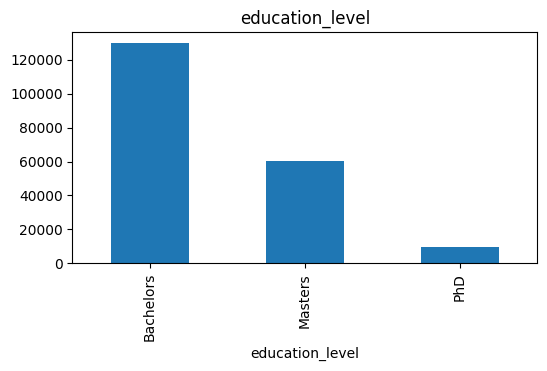

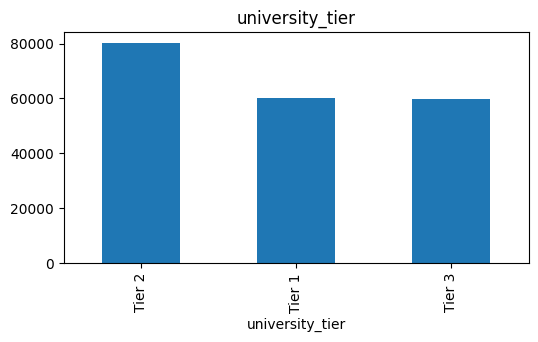

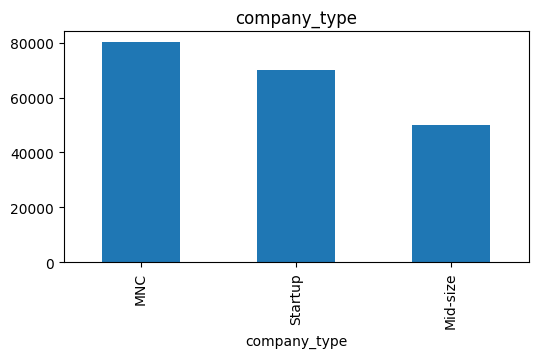

In [11]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(6,3))
    df[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.show()

#### Correlation

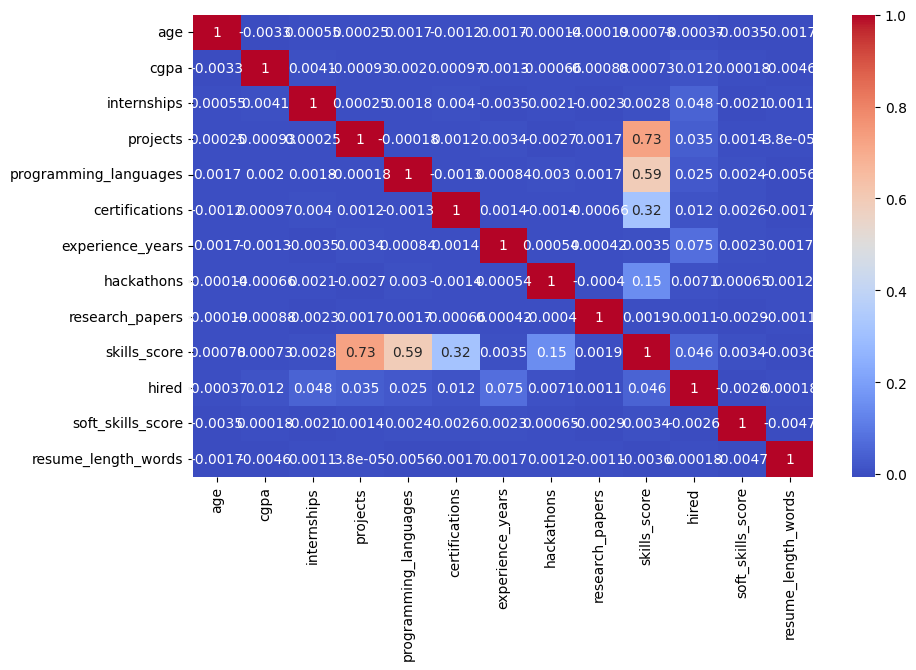

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

### Feature Engineering (Optional but Powerful)

In [13]:
df['total_experience_score'] = (
    df['internships'] + df['projects'] + df['certifications']
)

#### Define Target

In [14]:
target = 'hired'

X = df.drop(columns=[target])
y = df[target]

#### Train-Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#### Encoding Strategy

In [16]:
ordinal_cols = {
    'education_level': ['bachelors', 'masters', 'phd'],
    'university_tier': ['tier 3', 'tier 2', 'tier 1'],
    'company_type': ['startup', 'mid-size', 'mnc']
}

for col in ordinal_cols.keys():
    if col in X_train.columns:
        X_train[col] = X_train[col].str.lower().str.strip()
        X_test[col] = X_test[col].str.lower().str.strip()

#### Column Types

In [17]:
num_cols = X_train.select_dtypes(include=np.number).columns
cat_cols = X_train.select_dtypes(include='object').columns

nominal_cols = [col for col in cat_cols if col not in ordinal_cols.keys()]

#### Preprocessing Pipelines

In [18]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [19]:
ord_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=list(ordinal_cols.values()),
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

In [20]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])


In [21]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('ord', ord_pipeline, list(ordinal_cols.keys())),
    ('cat', cat_pipeline, nominal_cols)
])

#### Models

In [22]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(class_weight='balanced'),
    "XGBoost": XGBClassifier(scale_pos_weight=2, eval_metric='logloss')
}

#### TRAINING (SMOTE PIPELINE)

In [23]:
results = {}

for name, model in models.items():

    print(f"\n{name}")

    if name == "Naive Bayes":
        X_train_trans = preprocessor.fit_transform(X_train)
        X_test_trans = preprocessor.transform(X_test)

        sm = SMOTE(random_state=42)
        X_train_res, y_train_res = sm.fit_resample(X_train_trans, y_train)

        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_test_trans)

    else:
        pipe = ImbPipeline([
            ('preprocessor', preprocessor),
            ('smote', SMOTE(random_state=42)),
            ('model', model)
        ])

        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[name] = acc

    print("Accuracy:", acc)
    print("F1 Score:", f1)
    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy: 0.522
F1 Score: 0.5920631534030296
              precision    recall  f1-score   support

           0       0.33      0.60      0.42     11758
           1       0.74      0.49      0.59     28242

    accuracy                           0.52     40000
   macro avg       0.54      0.54      0.51     40000
weighted avg       0.62      0.52      0.54     40000


Naive Bayes
Accuracy: 0.483125
F1 Score: 0.5283018867924528
              precision    recall  f1-score   support

           0       0.32      0.66      0.43     11758
           1       0.74      0.41      0.53     28242

    accuracy                           0.48     40000
   macro avg       0.53      0.53      0.48     40000
weighted avg       0.62      0.48      0.50     40000


Decision Tree
Accuracy: 0.576275
F1 Score: 0.6923230526258464
              precision    recall  f1-score   support

           0       0.30      0.34      0.32     11758
           1       0.71      0.68      0.69    

In [25]:
results_df = pd.DataFrame(results.items(), columns=['Model', 'Accuracy',])
results_df = results_df.sort_values(by='Accuracy', ascending=False)

print(results_df)

                 Model  Accuracy
4              XGBoost  0.705925
3        Random Forest  0.689975
2        Decision Tree  0.576275
0  Logistic Regression  0.522000
1          Naive Bayes  0.483125


In [27]:
results_df_f1_score = pd.DataFrame(results.items(), columns=['Model', 'F1 Score'])

results_df_f1_score = results_df_f1_score.sort_values(by='F1 Score', ascending=False)

print(results_df_f1_score)

                 Model  F1 Score
4              XGBoost  0.705925
3        Random Forest  0.689975
2        Decision Tree  0.576275
0  Logistic Regression  0.522000
1          Naive Bayes  0.483125


#### GridSearchCV (WITH SMOTE PIPELINE)

##### XGBoost Tuning (BEST MODEL)

In [28]:
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(eval_metric='logloss'))
])

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.1],
    'model__subsample': [0.8, 1.0]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}
Best Score: 0.8276951030539683


##### Random Forest Tuning

In [29]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier())
])

param_grid_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20, None],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(
    pipe_rf,
    param_grid_rf,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

print("Best RF Params:", grid_rf.best_params_)
print("Best RF Score:", grid_rf.best_score_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best RF Params: {'model__max_depth': 20, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best RF Score: 0.8217928207224077


In [30]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.00      0.00     11758
           1       0.71      1.00      0.83     28242

    accuracy                           0.71     40000
   macro avg       0.71      0.50      0.41     40000
weighted avg       0.71      0.71      0.58     40000



In [31]:
import pickle

# Best pipeline from GridSearch
best_pipeline = grid.best_estimator_

# Save
with open("best_xgboost_model.pkl", "wb") as f:
    pickle.dump(best_pipeline, f)

print("Model saved successfully ✅")

Model saved successfully ✅
